# HRV Pipeline: Data Structuring & Preprocessing Setup

---

## Goal
This notebook contains Part 0 of the HRV pipeline.  
The goal of this stage is to convert raw WESAD data into a **structured format that's ready to be analyzed** so that it's easier for later HRV analysis and ML training. Here are the goals:

1. Plot emotion label distributions  
2. Draw emotion timelines  
3. Create `subject_summary.csv`  
4. Create `timeline_table.csv` (your Innovation #1) 

This step is all about **data structuring**, not modeling yet.

---
## 1. Set up

Here we are importing libraries and setting up file paths. Think of this as “clearing the desk before we start cooking.” :)

In [5]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# define where the raw WESAD data is stored
data_path = "../data/raw/WESAD"

# define where we will save output CSV files and plots
results_path = "../results"
os.makedirs(results_path, exist_ok=True)

print("Data path:", data_path)
print("Saving results to:", results_path)

Data path: ../data/raw/WESAD
Saving results to: ../results


---
## 2. Load Subjects

Here I'm building a small helper function to help load WESAD data. Since we’ll load S2, S3, S4, and S5 many times, I'm going to write a simple `load_subject()` so we don’t repeat code.

In [6]:
def load_subject(subj):
    """
    Loads a WESAD subject's .pkl file.

    Parameters
    ----------
    subj : str
        Example: "S2"

    Returns
    -------
    data : dict
        A dictionary containing:
        - data["signal"] : sensor signals (ECG, EDA, etc.)
        - data["label"]  : emotion labels
        - data["subject"] : metadata
    """
    
    # construct the full file path
    file_path = os.path.join(data_path, subj, f"{subj}.pkl")
    
    # open and load the pickle file
    with open(file_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")     # latin1 avoids encoding issues
    return data

# the subjects we will work on
subjects = ["S2", "S3", "S4", "S5"]
print("Working on:", subjects)

Working on: ['S2', 'S3', 'S4', 'S5']


---
## 3. Label Distribution

We'll look at the emotion label distribution for each subject. This helps us understand:
- How long each subject spent in baseline / stress / amusement  
- Whether the data is balanced or not  
- Whether some subjects have much shorter stress or amusement phases  

We’ll plot a pie chart + a simple bar graph.

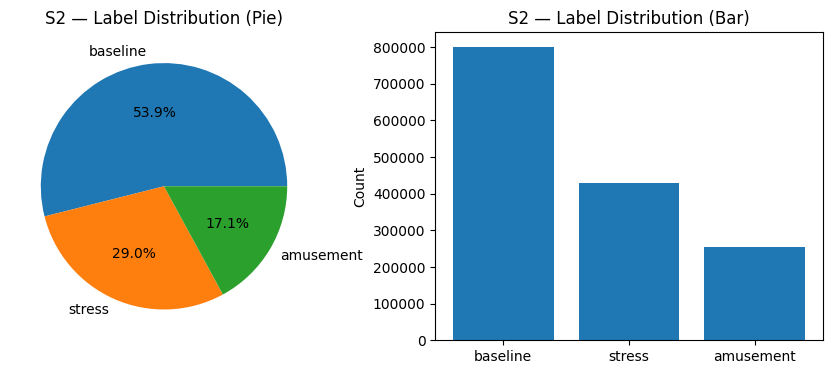

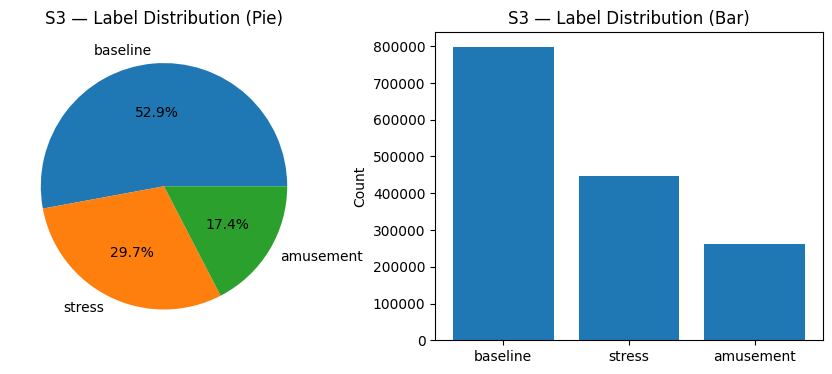

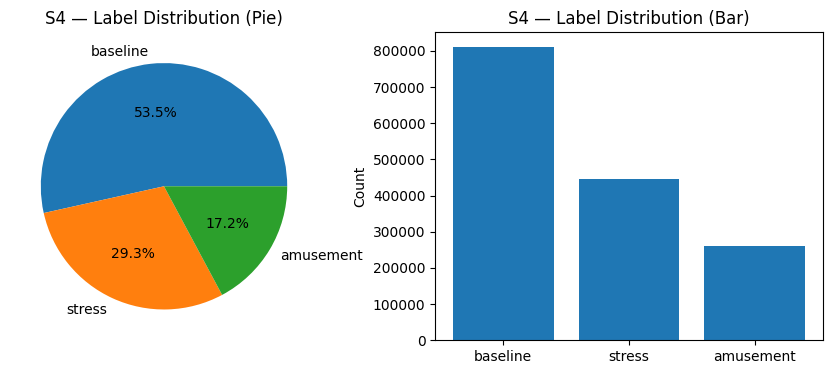

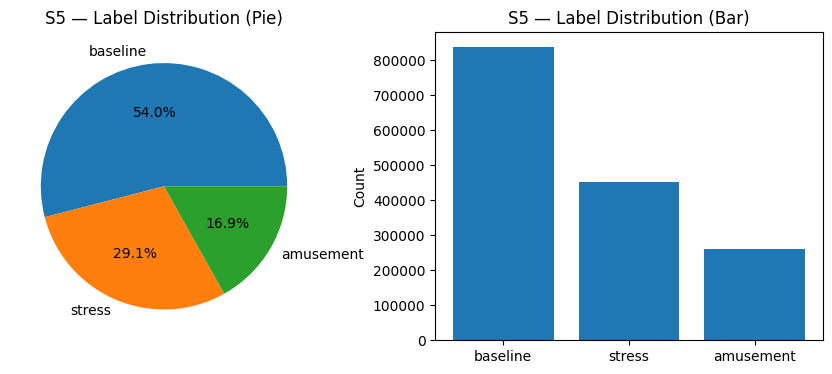

In [7]:
# map numeric labels to readable names
label_map = {1: "baseline", 2: "stress", 3: "amusement"}

for subj in subjects:
    data = load_subject(subj)
    labels = data["label"]     # 1D array of emotion labels

    unique_vals, counts = np.unique(labels, return_counts=True)
    raw_counts = dict(zip(unique_vals, counts))         # {label: count}

    # only keep labels that we care about, which are 1,2 and 3
    filtered = {
            label_map[k]: v for k, v in raw_counts.items() if k in label_map
    }

    plt.figure(figsize=(11,4))

    # pie chart
    plt.subplot(1,2,1)
    plt.pie(filtered.values(),
            labels=list(filtered.keys()),
            autopct="%1.1f%%")
    plt.title(f"{subj} — Label Distribution (Pie)")

    # bar chart
    plt.subplot(1,2,2)
    plt.bar(filtered.keys(), filtered.values())
    plt.title(f"{subj} — Label Distribution (Bar)")
    plt.ylabel("Count")

    plt.show()

---
## 4. Emotion Timeline

I'll plot a colored "emotion timeline" for each subject. Each sample gets a color depending on its emotion. This is a super intuitive visualization:

- Each sample is a point  
- Its color shows which emotion the subject was experiencing  
- The entire timeline shows how emotions evolve across the session  

In other words, we will be able to tell:
- when baseline happened  
- when it switched to stress  
- when amusement starts  
- this also confirms whether emotions appear in clean blocks


Later when we build HRV windows, this visual intuition will help.

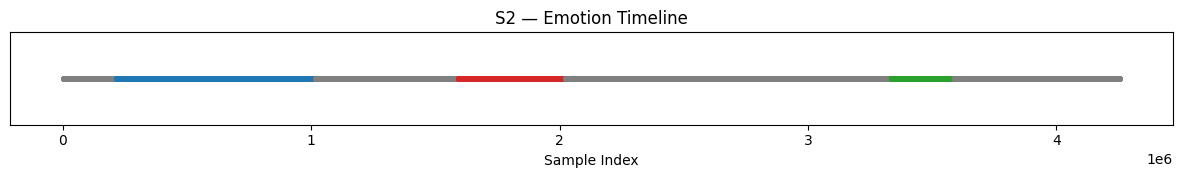

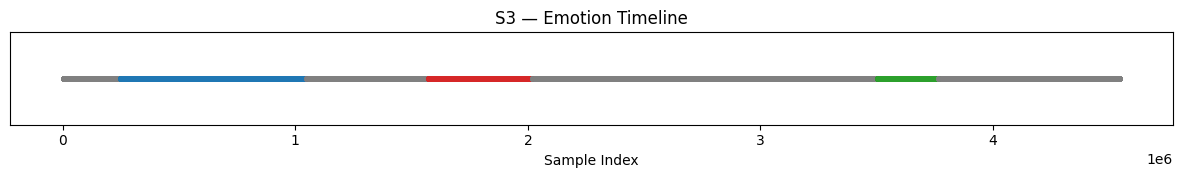

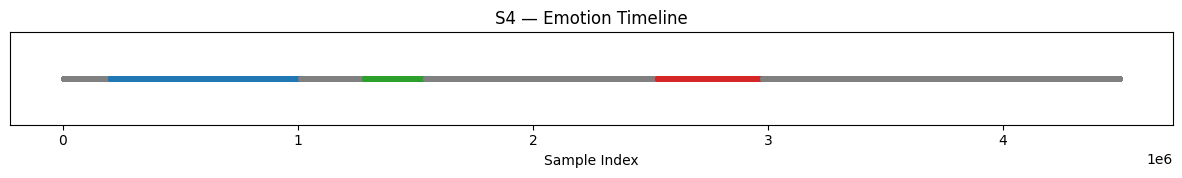

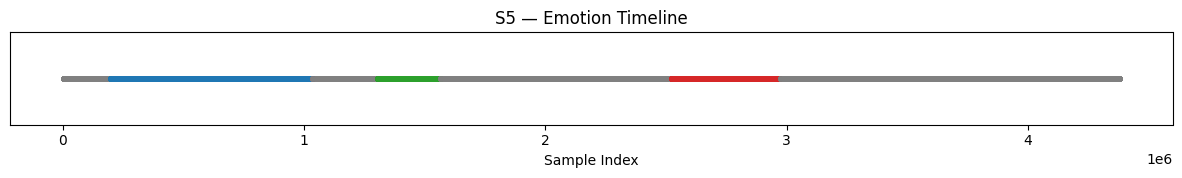

In [8]:
def plot_timeline(labels, subj):
    """
    Create a horizontal color-coded timeline of emotions.

    Each sample is a dot.
    Colors:
        baseline  -> blue
        stress    -> red
        amusement -> green
    """
    
    color_map = {
        1:"tab:blue", 
        2:"tab:red", 
        3:"tab:green"
    }
    
    # convert label array into color array
    colors = [color_map.get(x, "gray") for x in labels]

    # make a long scatter plot
    plt.figure(figsize=(15,1.2))
    plt.scatter(
        np.arange(len(labels)),              # x_axis = sample index
        np.zeros(len(labels)),               # y-axis = all 0s. it will be a flat line
        c=colors, 
        s=3, 
        marker="s"                           # square markers to look like a timeline
    )
    plt.title(f"{subj} — Emotion Timeline")
    plt.yticks([])
    plt.xlabel("Sample Index")
    plt.show()

for subj in subjects:
    plot_timeline(load_subject(subj)["label"], subj)

---
## 5. Create `subject_summary.csv` 

This is to show how many minutes each emotion lasted. It's a quick overview of the dataset’s balance. It tells us
- How long each subject was recorded  
- How long they spent in baseline / stress / amusement  
- Whether some subjects are skewed or missing data  

In [9]:
summary_rows = []        # will store table rows

for subj in subjects:
    labels = load_subject(subj)["label"]        # emotion array

    # compute durations is needed because
    # WESAD is sampled at 700Hz, but labels are per-second
    total_min = len(labels) / 60
    total_min = len(labels) / 60
    baseline_min = np.sum(labels == 1) / 60
    stress_min = np.sum(labels == 2) / 60
    amusement_min = np.sum(labels == 3) / 60

    # add to summary list
    summary_rows.append([
        subj, 
        total_min, 
        baseline_min, 
        stress_min, 
        amusement_min
    ])

# convert to DataFrame
summary_df = pd.DataFrame(summary_rows, columns=[
    "subject", "total_min", "baseline_min", "stress_min", "amusement_min"
])

# save CSV
summary_file = os.path.join(results_path, "subject_summary.csv")
summary_df.to_csv(summary_file, index=False)

summary_df

,subject,total_min,baseline_min,stress_min,amusement_min
0,S2,70921.666667,13346.666667,7175.000000,4223.333333
1,S3,75751.666667,13300.000000,7466.666667,4375.000000
2,S4,74935.000000,13510.016667,7408.333333,4340.000000
3,S5,73010.000000,13976.666667,7525.000000,4363.333333


---
## 6. Innovation #1    
## Build a clean `timeline_table.csv`

This is one of the most important files in the whole Echo pipeline!

Instead of *assuming* baseline/stress/amusement durations, we will **scan the raw label array** and detect the exact boundaries where each emotion starts and ends.

The table looks like this:

| subject | start_sec | end_sec | label |

This is the key file that will let us correctly align HRV windows  
with their true emotion labels.


In [12]:
def build_timeline(labels, subj):
    """
    Convert the raw label array into clean emotion segments. 
    This is essential for accurate HRV window label alignment.
    Returns rows of: [subject, start_sec, end_sec, label_string]
    """
    segments = []               # will store timeline segments
    current_label = labels[0]   # starting label
    start = 0                   # starting index of current segment

    # loop through labels to detect label transitions
    for i in range(1, len(labels)):
        if labels[i] != current_label:
            # emotion changed, close the previous segment
            segments.append([
                subj, start, i, label_map.get(current_label, "other")
            ])
            # start new segment
            start = i
            current_label = labels[i]

    # final segment
    segments.append([
        subj, start, len(labels), label_map.get(current_label, "other")
    ])
    return segments

# collect timeline rows for all subjects
timeline_rows = []
for subj in subjects:
    labels = load_subject(subj)["label"]
    timeline_rows.extend(build_timeline(labels, subj))

# make DataFrame
timeline_df = pd.DataFrame(timeline_rows, columns=[
    "subject", "start_sec", "end_sec", "label"
])

timeline_file = os.path.join(results_path, "timeline_table.csv")
timeline_df.to_csv(timeline_file, index=False)

# show a few rows
timeline_df.head(60)

,subject,start_sec,end_sec,label
0,S2,0,214583,other
1,S2,214583,1015383,baseline
2,S2,1015383,1591482,other
3,S2,1591482,2021982,stress
4,S2,2021982,2212383,other
5,S2,2212383,2257883,other
6,S2,2257883,2868283,other
7,S2,2868283,3141982,other
8,S2,3141982,3334483,other
9,S2,3334483,3587883,amusement
